In [ ]:
!pip install mne


In [1]:
# Install and test autoreject
#!conda install -c autoreject
import autoreject

In [7]:
import os
import numpy as np
import pandas as pd
import glob

import mne



In [8]:
# Listing folder and files
# Listing folder and files
data_path = "/Users/alicerueda/Documents/TI EEG/"
print(data_path)
eeg_files = glob.glob(data_path+"*Con*.bdf")
eeg_file = eeg_files[0]
eeg_file



/Users/alicerueda/Documents/TI EEG/


'/Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Concurrent_20240209.bdf'

In [9]:
eeg_file = eeg_files[0]
eeg_file

'/Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Concurrent_20240209.bdf'

In [ ]:
# Loading data (raw) and set to the proper channels
raw = mne.io.read_raw_bdf(eeg_file, preload=True)
biosemi32_montage = mne.channels.make_standard_montage('biosemi32')
raw.set_montage(biosemi32_montage, on_missing='ignore')

print(raw.info["bads"])
raw = raw.drop_channels(['AF1', 'AF2'])




Extracting EDF parameters from /Users/alicerueda/Documents/TI EEG/TI-MDD_TI00_V1_Concurrent_20240209.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7929855  =      0.000 ...  1936.000 secs...


<RawEDF | TI-MDD_TI00_V1_Concurrent_20240209.bdf, 48 x 7929856 (1936.0 s), ~2.84 GB, data loaded>

In [11]:
# Set EOG channels to EXG3, EXG4, EXG5, and EXG6
eog_channels = ['EXG3', 'EXG4', 'EXG5', 'EXG6']
raw.set_channel_types({ch: 'eog' for ch in eog_channels})
# ecg_channel
raw.set_channel_types({'EXG7': 'ecg'})

#data.ch_names[34:38] = ['HLEOG', 'HREOG', 'VLEOG', 'VREOG']
raw.ch_names

['Fp1',
 'AF3',
 'F7',
 'F3',
 'FC1',
 'FC5',
 'T7',
 'C3',
 'CP1',
 'CP5',
 'P7',
 'P3',
 'Pz',
 'PO3',
 'O1',
 'Oz',
 'O2',
 'PO4',
 'P4',
 'P8',
 'CP6',
 'CP2',
 'C4',
 'T8',
 'FC6',
 'FC2',
 'F4',
 'F8',
 'AF4',
 'Fp2',
 'Fz',
 'Cz',
 'EXG1',
 'EXG2',
 'EXG3',
 'EXG4',
 'EXG5',
 'EXG6',
 'EXG7',
 'EXG8',
 'GSR1',
 'GSR2',
 'Erg1',
 'Erg2',
 'Resp',
 'Plet',
 'Temp',
 'Status']

In [12]:
# use average of mastoid channels as reference
raw.set_eeg_reference(ref_channels=['EXG1', 'EXG2'])
#raw.set_eeg_reference(ref_channels='average')



EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


<RawEDF | TI-MDD_TI00_V1_Concurrent_20240209.bdf, 48 x 7929856 (1936.0 s), ~2.84 GB, data loaded>

Using matplotlib as 2D backend.


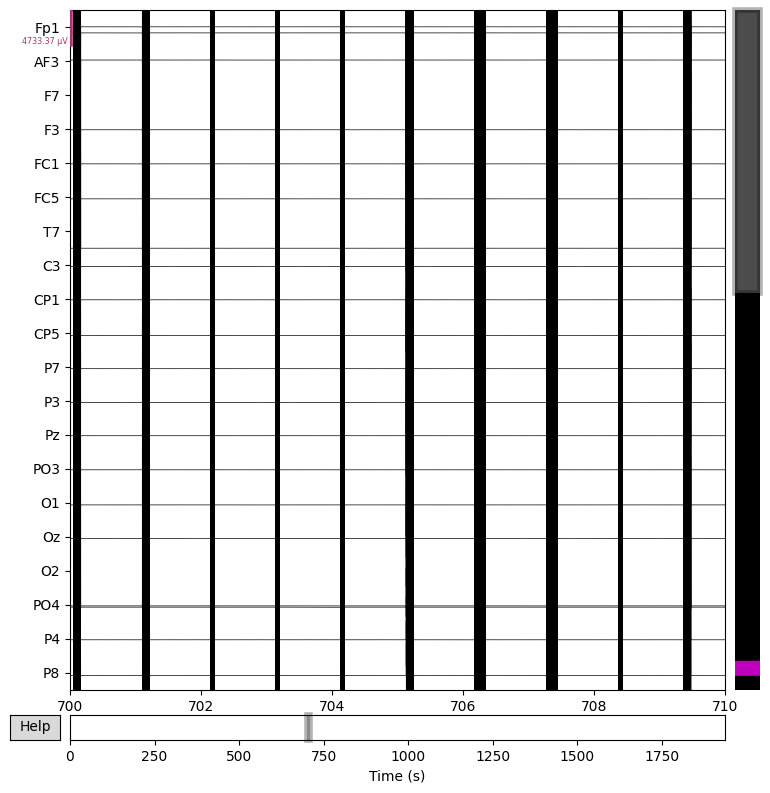

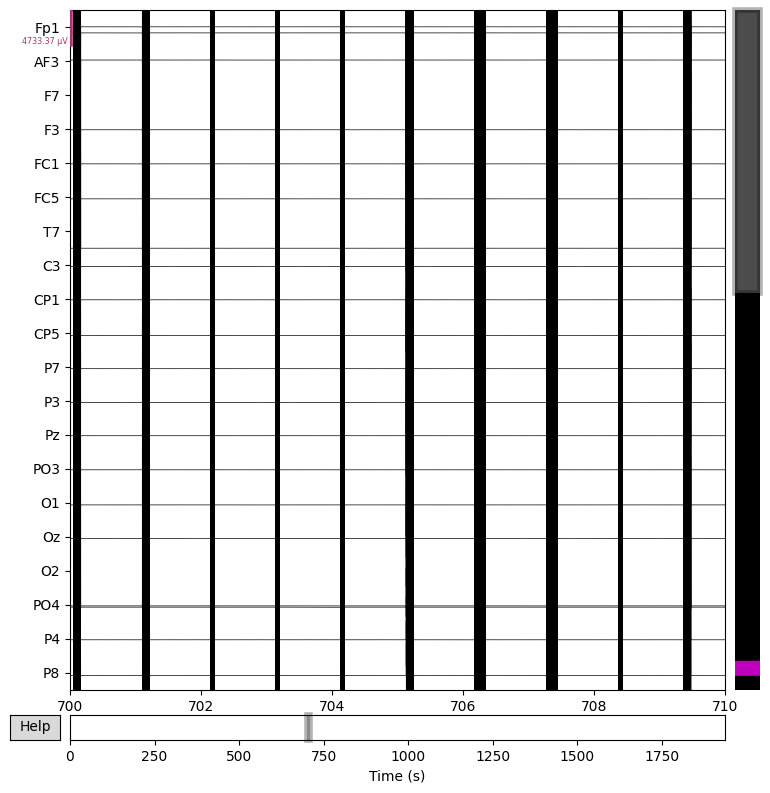

In [13]:
# add new reference channel (all zero)
#raw_new_ref = mne.add_reference_channels(raw, ref_channels=['EXG1', 'EXG2'])
raw.plot(start = 700, duration = 10, clipping=None, scalings='auto')

In [14]:
raw.drop_channels(['T7','T8','F7','F8'])

<RawEDF | TI-MDD_TI00_V1_Concurrent_20240209.bdf, 44 x 7929856 (1936.0 s), ~2.60 GB, data loaded>

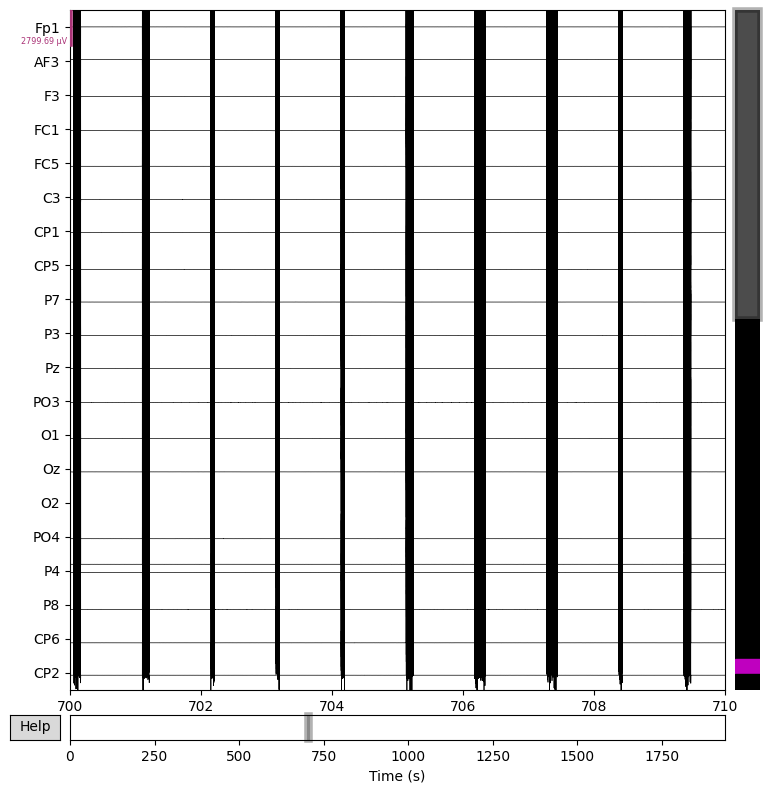

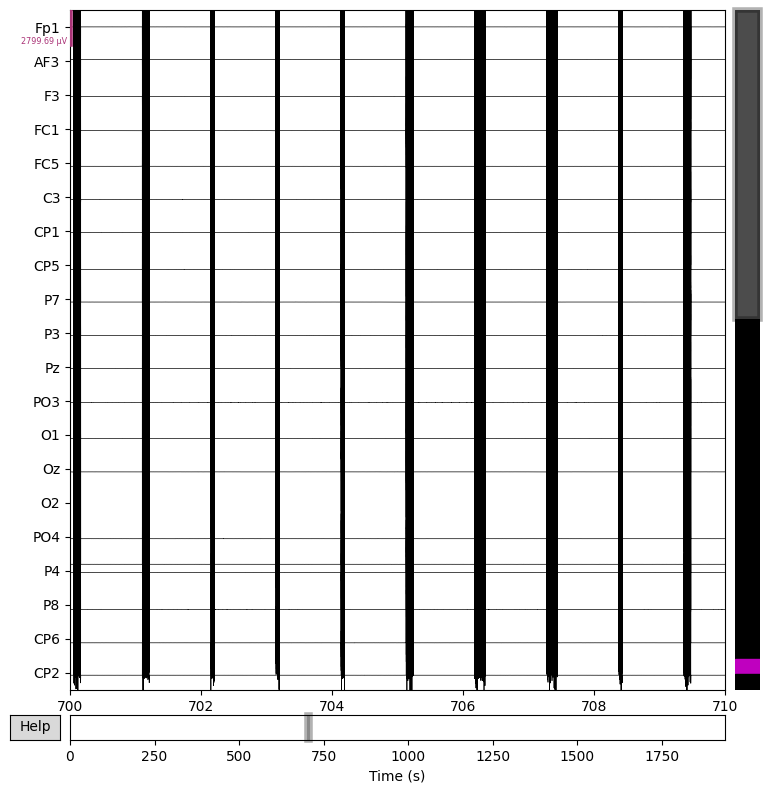

In [10]:
raw.plot(start = 700, duration = 10, clipping=None, scalings='auto')

In [ ]:
raw.drop_channels(['EXG1','EXG2','EXG8','GSR1','GSR2',
                    'Erg1', 'Erg2', 'Resp','Plet','Temp'])

In [ ]:
raw.plot(start = 1500, duration = 10, clipping=None, scalings='auto')

In [10]:
# filtering
'''
for cutoff in (0.1, 0.2, 0.5):
    raw_highpass = raw.copy().filter(l_freq=cutoff, h_freq=None)
    with mne.viz.use_browser_backend("matplotlib"):
        fig = raw_highpass.plot(
            duration=60, proj=False, n_channels=len(raw.ch_names), remove_dc=False
        )
    fig.subplots_adjust(top=0.9)
    fig.suptitle(f"High-pass filtered at {cutoff} Hz", size="xx-large", weight="bold")
    
'''


'\nfor cutoff in (0.1, 0.2, 0.5):\n    raw_highpass = raw.copy().filter(l_freq=cutoff, h_freq=None)\n    with mne.viz.use_browser_backend("matplotlib"):\n        fig = raw_highpass.plot(\n            duration=60, proj=False, n_channels=len(raw.ch_names), remove_dc=False\n        )\n    fig.subplots_adjust(top=0.9)\n    fig.suptitle(f"High-pass filtered at {cutoff} Hz", size="xx-large", weight="bold")\n    \n'

In [12]:
print(raw)

n_time_samps = raw.n_times
time_secs = raw.times
ch_names = raw.ch_names
n_chan = len(ch_names)  # note: there is no raw.n_channels attribute
print(
    f"the (cropped) sample data object has {n_time_samps} time samples and "
    f"{n_chan} channels."
)
print(f"The last time sample is at {time_secs[-1]} seconds.")
print("The first few channel names are {}.".format(", ".join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print("bad channels:", raw.info["bads"])  # chs marked "bad" during acquisition
print(raw.info["sfreq"], "Hz")  # sampling frequency
print(raw.info["description"], "\n")  # miscellaneous acquisition info

print(raw.info)

<RawEDF | NFRF-007-MMN-V2-2023_11_30.bdf, 38 x 578048 (1129.0 s), ~167.6 MB, data loaded>
the (cropped) sample data object has 578048 time samples and 38 channels.
The last time sample is at 1128.998046875 seconds.
The first few channel names are Fp1, AF3, F7.

bad channels: []
512.0 Hz
None 

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG, 4 EOG, 1 ECG, 1 Stimulus
 custom_ref_applied: True
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 104.0 Hz
 meas_date: 2023-11-30 06:28:57 UTC
 nchan: 38
 projs: []
 sfreq: 512.0 Hz
>


In [12]:
# print(raw.time_as_index(20))   #20x512
# print(raw.time_as_index([20, 30, 40]), "\n")

# print(np.diff(raw.time_as_index([1, 2, 3])))

# Events

We do not have annotation on the events, but numberes. 

In [13]:
# events label extaction
event_from_labels, event_dict = mne.events_from_annotations(raw)

print(event_dict)

events = mne.find_events(raw)
print(events)

event_dict={'tone1': 1, 'tone2':2}

{}
Trigger channel has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
3603 events found
Event IDs: [  1   2   4  32  64  99 128 129]
[[ 11722      0     99]
 [ 16914      0      4]
 [ 20257      0      1]
 ...
 [572781      0    128]
 [572966      0      1]
 [573112      0    128]]


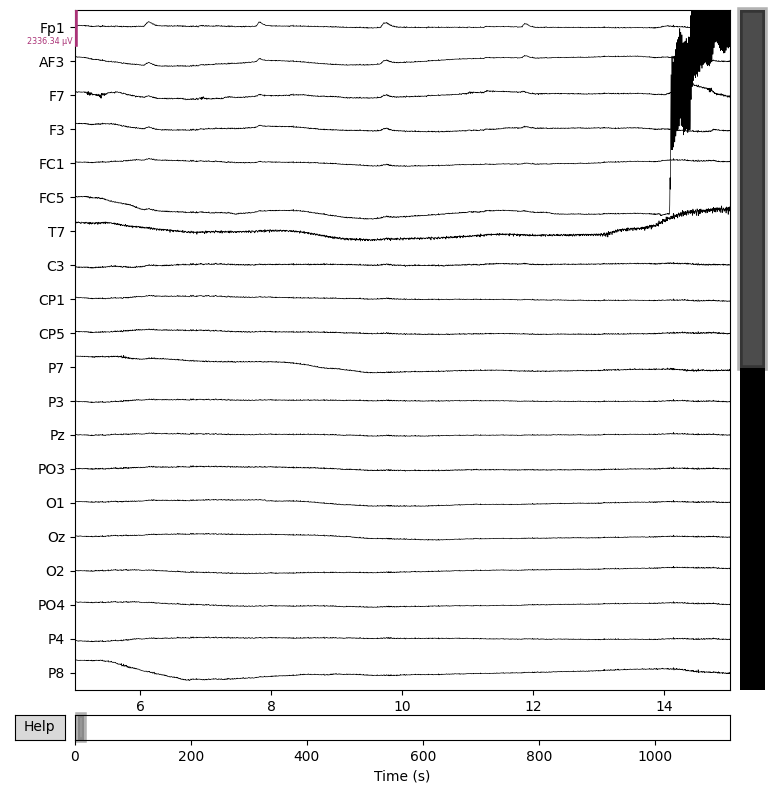

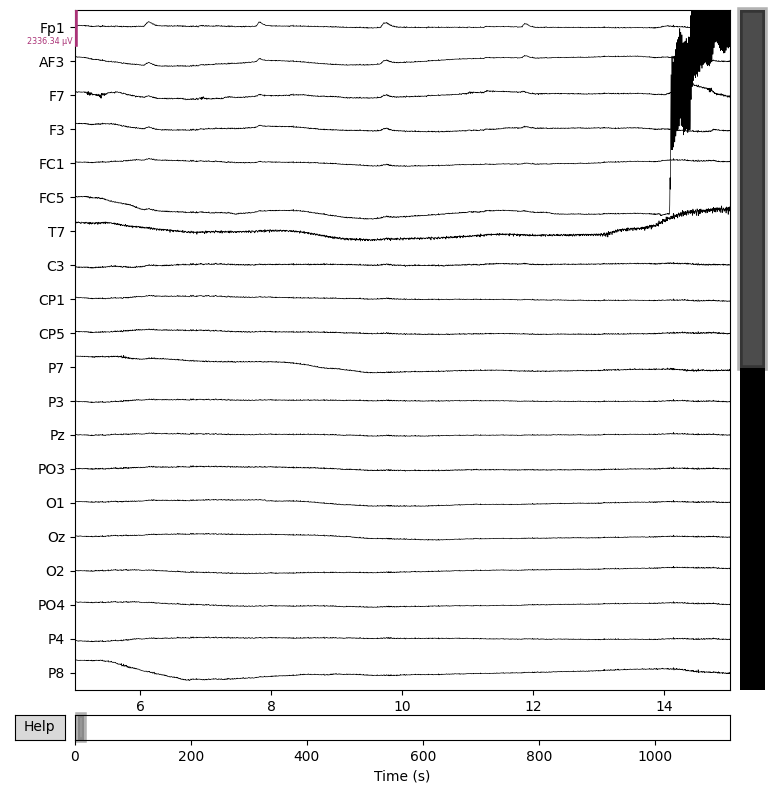

In [14]:
'''
event_dict = {
    "Tone1": 1,  # 1 is also start
    "Tone2": 2,
    "TriggerInst": 4,
    "VisualRight": 32,
    "VisualLeft": 64,
    "Start": 99,
    "VisualDummy":128,
    "End": 129
    
}
1   2   4  32  64  99 128 129

'''


raw.plot(events=events, start=5, duration = 10, color = 'black',
         event_color = {1:'r', 2:'g', 4:'b', 32:'m', 64:'y', 99:'k', 128:'k', 129:'k'},
         clipping=None, scalings='auto')

# Basic EEG Filtering

Not setting metadata
1800 matching events found
Setting baseline interval to [-0.099609375, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1800 events and 257 original time points ...
0 bad epochs dropped


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:5: RuntimeWarning: event 4 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:5: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:5: RuntimeWarning: event 64 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:5: RuntimeWarning: event 99 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:5: RuntimeWarning: event 128 missing from event_id will be ignored
  fig = mne.viz.plot_events(


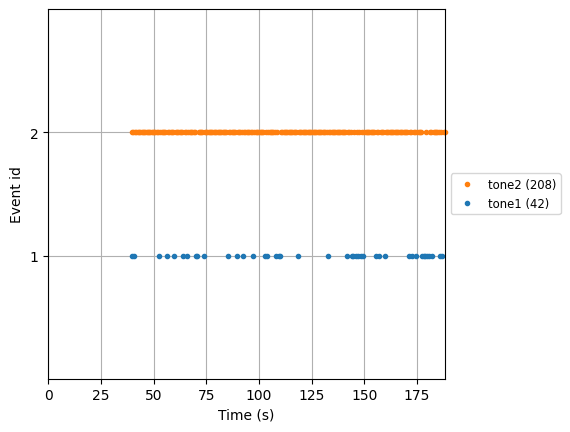

[[ 11722      0     99]
 [ 16914      0      4]
 [ 20257      0      1]
 ...
 [572781      0    128]
 [572966      0      1]
 [573112      0    128]]


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:11: RuntimeWarning: event 4 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:11: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:11: RuntimeWarning: event 64 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:11: RuntimeWarning: event 99 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:11: RuntimeWarning: event 128 missing from event_id will be ignored
  fig = mne.viz.plot_events(
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/1345406485.py:11: RuntimeWarning: event 129 missing from eve

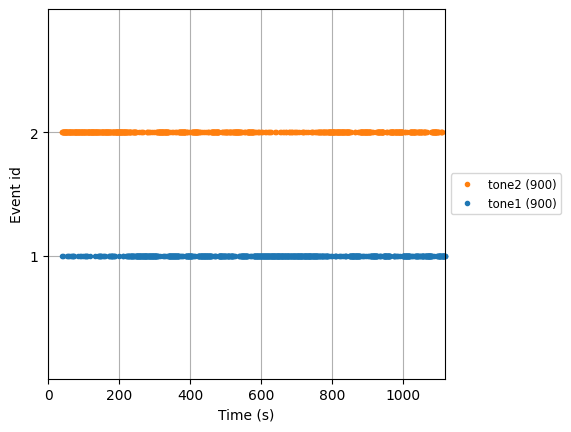

In [15]:
# Extract Epochs

epochs = mne.Epochs(raw, events, tmin=-0.1, tmax=0.4, event_id=event_dict, preload= True)

fig = mne.viz.plot_events(
    events[0:500], sfreq=raw.info["sfreq"], first_samp=raw.first_samp, event_id=event_dict
)

print(events)

fig = mne.viz.plot_events(
    events, sfreq=raw.info["sfreq"], first_samp=raw.first_samp, event_id=event_dict
)


In [16]:
epochs

Number of events,1800
Events,tone1: 900tone2: 900
Time range,-0.100 – 0.400 sec
Baseline,-0.100 – 0.000 sec


In [32]:
# Filter the data
filtered_raw = raw.filter(0.5, 40,fir_design='firwin', n_jobs=2)
#raw.filter(0.5, 40, fir_design='firwin')  # Example: bandpass filter between 0.5 and 40 Hz


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 27035 samples (6.600 sec)



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  16 tasks      | elapsed:    5.3s
[Parallel(n_jobs=2)]: Done  42 out of  42 | elapsed:   16.8s finished


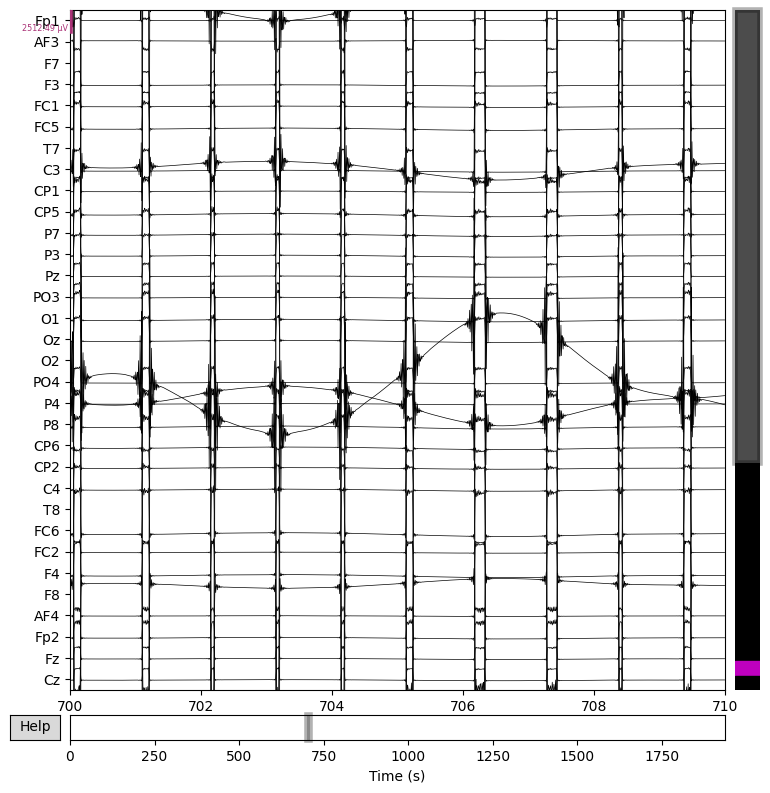

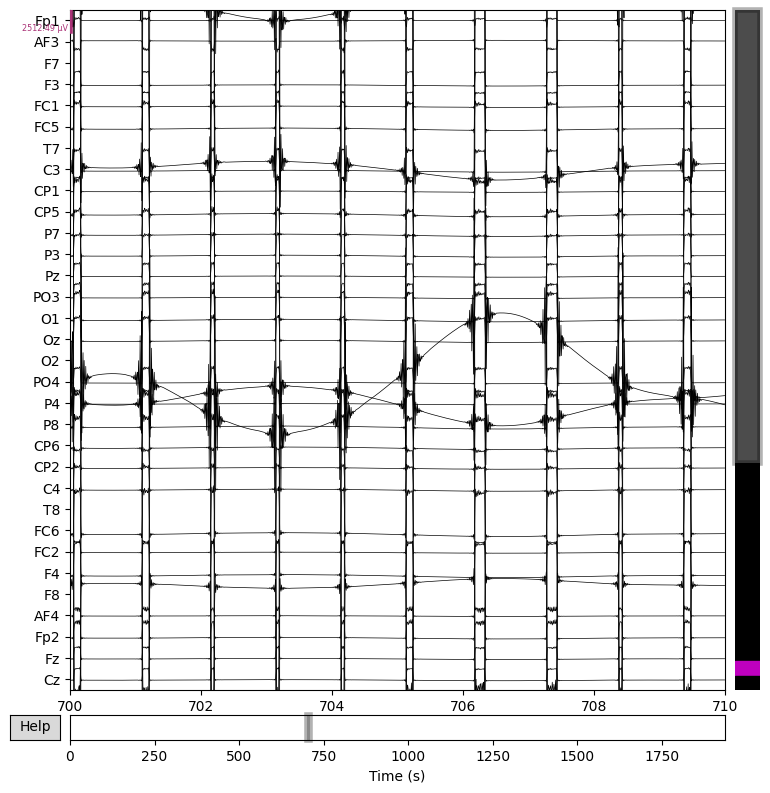

In [33]:
filtered_raw.plot(
          start=700,
          duration=10, 
          n_channels=32,
          clipping=None, 
          scalings='auto'
         )


In [ ]:
# Remove artifacts
# You can use ICA or other artifact removal techniques here
# Example using ICA
#ica = mne.preprocessing.ICA(n_components=20, random_state=100, max_iter=800)
ica = mne.preprocessing.ICA(random_state=100, max_iter=800)
ica.fit(epochs)

#ica.exclude = [0, 1]  # indices of components to exclude
#ica.apply(raw)

iclabels = label_components(filtered_raw, ica, method="iclabel")

Fitting ICA to data using 32 channels (please be patient, this may take a while)


/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/3279401631.py:6: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs)
/var/folders/2z/3605cmvj5fs3kvmbmpdh19hc0000gn/T/ipykernel_86704/3279401631.py:6: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs)


Selecting by non-zero PCA components: 32 components
Fitting ICA took 52.1s.


Method,fastica
Fit,105 iterations on epochs (462600 samples)
ICA components,32
Available PCA components,32
Channel types,eeg
ICA components marked for exclusion,—


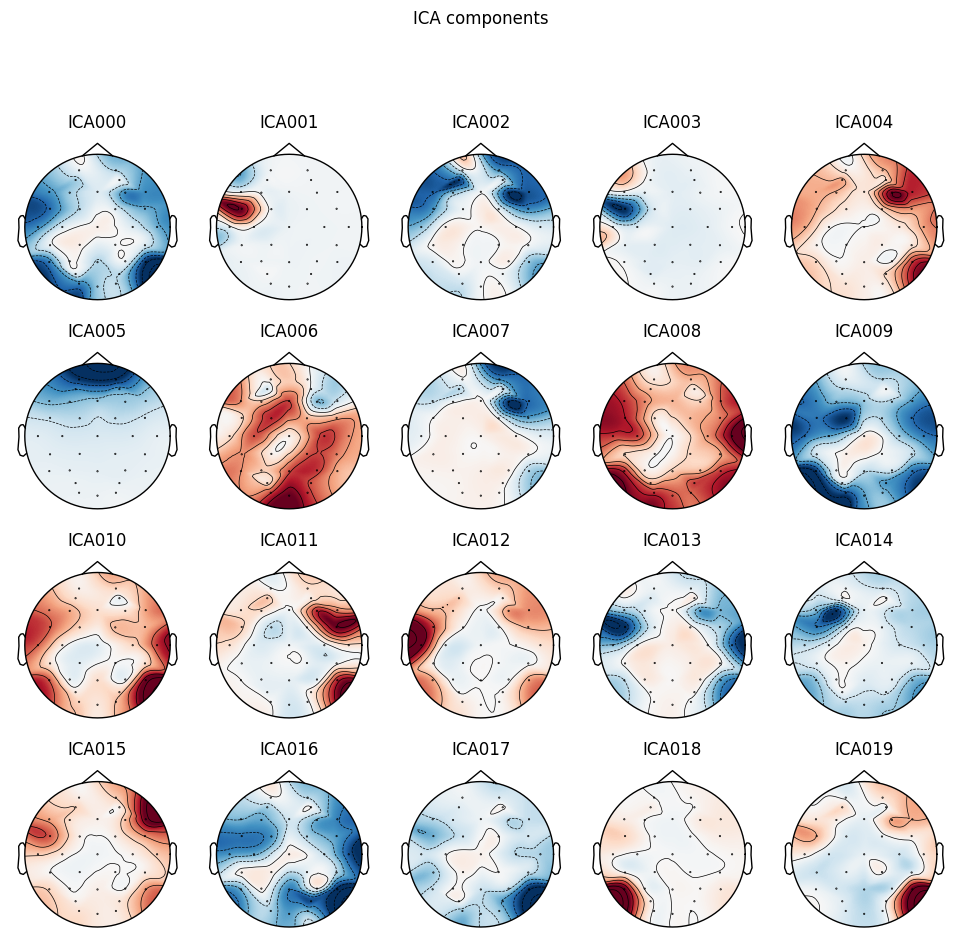

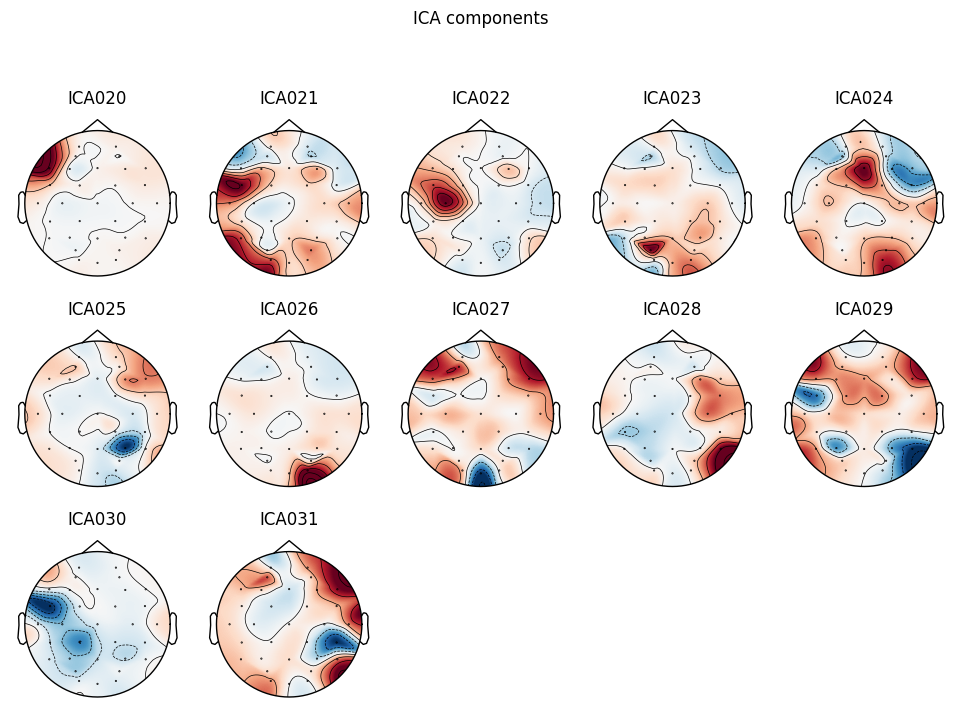

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x731.5 with 12 Axes>]

In [26]:
ica.plot_components()

# Autoreject

In [2]:
ar = autoreject.AutoReject(n_interpolate=[1, 2, 3, 4], random_state=11,
                           n_jobs=1, verbose=True)
ar.fit(epochs[:20])  # fit on a few epochs to save time
epochs_ar, reject_log = ar.transform(epochs, return_log=True)

NameError: name 'autoreject' is not defined

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'autoreject'
